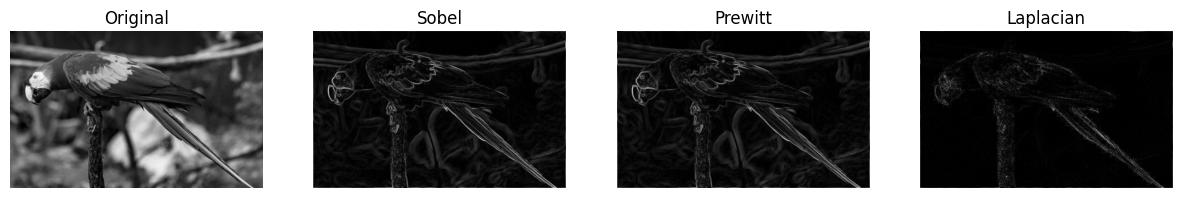

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('pillows.jpg')   # Upload any image to Colab
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant'
    )

    output = np.zeros((h, w))

    for i in range(h):
        for j in range(w):

            region = padded[i:i+kh, j:j+kw]

            value = np.sum(region * kernel)

            output[i, j] = value

    return output

# Sobel X
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Sobel Y
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# Prewitt X
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

# Prewitt Y
prewitt_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

# Laplacian
laplacian = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
])

gx = convolve(gray, sobel_x)
gy = convolve(gray, sobel_y)

sobel_edges = np.sqrt(gx**2 + gy**2)

px = convolve(gray, prewitt_x)
py = convolve(gray, prewitt_y)

prewitt_edges = np.sqrt(px**2 + py**2)

laplacian_edges = np.abs(convolve(gray, laplacian))

def normalize(img):
    img = img - img.min()
    img = img / img.max()
    return (img * 255).astype(np.uint8)

sobel_edges = normalize(sobel_edges)
prewitt_edges = normalize(prewitt_edges)
laplacian_edges = normalize(laplacian_edges)

plt.figure(figsize=(15,8))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(prewitt_edges, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian")
plt.axis('off')

plt.show()